In [ ]:


import pandas as pd
import numpy as np
from google.colab import files


vpt_shift = 2.5         # reduced mean shift for CIPN cases (μm)
cold_shift = -0.7       # reduced cold shift for CIPN (°C)
sd_multiplier = 1.5     # inflate SDs to increase overlap
apply_prob = 0.80       # fraction of label==1 cases that show the shift
mislabel_rate = 0.05    # fraction of rows to flip label (noise)
seed_main = 1234        # RNG seed

output_filename = 'cipn_generated_more_realistic.csv'
# -------------------------

np.random.seed(seed_main)


try:
    base = pd.read_csv('cipn_cancer_drug_only.csv')
    print("Loaded uploaded 'cipn_cancer_drug_only.csv' with", len(base), "rows.")
except Exception:
    print("No base CSV found. Creating a synthetic base (2200 rows).")
    n = 2200
    base = pd.DataFrame({
        'cancer_type': np.random.choice(
            ['Breast cancer','Lung cancer','Colorectal cancer','Ovarian cancer'],
            size=n, p=[0.5, 0.2, 0.2, 0.1]
        ),
        'drug_type': np.random.choice(['taxane','platinum','mixed (taxane, platinum, others)'],
                                      size=n),
    })
    # synthetic label ~35% positive
    base['label'] = (np.random.rand(n) < 0.35).astype(int)

df = base.copy()

# Ensure label column exists and is int
if 'label' not in df.columns:
    df['label'] = (np.random.rand(len(df)) < 0.35).astype(int)
df['label'] = df['label'].astype(int)

# -------------------------
# Sex assignment:
# Breast cancer -> 1% male
# Others -> 40% male
# -------------------------
np.random.seed(42)
sexs = []
for _, row in df.iterrows():
    if str(row.get('cancer_type','')).strip().lower() == 'breast cancer':
        sexs.append('M' if np.random.rand() <= 0.01 else 'F')
    else:
        sexs.append(np.random.choice(['M', 'F'], p=[0.4, 0.6]))
df['sex'] = sexs

# -------------------------
# Age and groups
# -------------------------
if 'age' not in df.columns:
    np.random.seed(1)
    df['age'] = np.random.randint(30, 75, size=len(df))
bins = [30, 45, 60, 75]
labels = ['Young', 'Middle', 'Old']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# -------------------------
# Reference table (your values)
# -------------------------
ref = {
    'Young': {
        'M': {'vpt_mean': 3.0, 'vpt_sd': 0.6, 'cold_mean': 30.7, 'cold_sd': 0.8},
        'F': {'vpt_mean': 2.6, 'vpt_sd': 0.5, 'cold_mean': 31.0, 'cold_sd': 0.7},
    },
    'Middle': {
        'M': {'vpt_mean': 4.5, 'vpt_sd': 1.0, 'cold_mean': 30.2, 'cold_sd': 1.0},
        'F': {'vpt_mean': 4.0, 'vpt_sd': 0.9, 'cold_mean': 30.7, 'cold_sd': 0.8},
    },
    'Old': {
        'M': {'vpt_mean': 7.0, 'vpt_sd': 1.5, 'cold_mean': 29.5, 'cold_sd': 0.9},
        'F': {'vpt_mean': 6.2, 'vpt_sd': 1.4, 'cold_mean': 30.0, 'cold_sd': 0.9},
    }
}

# -------------------------
# Generate VPT and cold_temp with reduced effect + noise
# -------------------------
np.random.seed(seed_main)
vpt_vals = []
cold_vals = []
for _, row in df.iterrows():
    ag = row['age_group']
    sex = row['sex']
    label = int(row['label'])
    # fallback
    if pd.isna(ag) or sex not in ['M', 'F']:
        ag = 'Middle'; sex = 'F'
    r = ref[ag][sex]
    vsd = r['vpt_sd'] * sd_multiplier
    csd = r['cold_sd'] * sd_multiplier
    # probabilistic application of the CIPN shift
    if label == 1 and np.random.rand() < apply_prob:
        vmean = r['vpt_mean'] + vpt_shift
        cmean = r['cold_mean'] + cold_shift
    else:
        vmean = r['vpt_mean']
        cmean = r['cold_mean']
    v = np.random.normal(vmean, vsd)
    c = np.random.normal(cmean, csd)
    vpt_vals.append(round(max(0.1, v), 2))
    cold_vals.append(round(float(c), 2))
df['vpt'] = vpt_vals
df['cold_temp'] = cold_vals

# -------------------------
# Simulate 'drives' and CIPN20 items (weaker effect)
# - item 19 = driving question -> NaN if not driving
# - item 20 = male sexual function -> NaN if female
# -------------------------
np.random.seed(2023)
drive_probs = df['age'].apply(lambda a: 0.85 if a < 60 else 0.45)
df['drives'] = (np.random.rand(len(df)) < drive_probs).astype(bool)

np.random.seed(2025)
def gen_item_probs(label, base_prob, shift=0.08):
    """Base distribution for 1..4 responses; smaller 'shift' for CIPN cases."""
    probs = np.array(base_prob, dtype=float)
    if label == 1:
        probs[0] = max(0, probs[0] - 0.7 * shift)
        probs[1] = max(0, probs[1] - 0.2 * shift)
        probs[2] = max(0, probs[2] + 0.6 * shift)
        probs[3] = max(0, probs[3] + 0.3 * shift)
    probs = probs / probs.sum()
    return probs

base_prob_sensory = [0.55, 0.30, 0.10, 0.05]
base_prob_motor   = [0.60, 0.28, 0.08, 0.04]
base_prob_autonomic = [0.70, 0.22, 0.06, 0.02]

sensory_idx = list(range(1, 10))
motor_idx = list(range(10, 18))
autonomic_idx = list(range(18, 21))

for i in range(1, 21):
    col = f'cipn20_i{i}'
    vals = []
    for _, row in df.iterrows():
        label = int(row['label'])
        # conditional items
        if i == 19:
            if not row['drives']:
                vals.append(np.nan)
                continue
            probs = gen_item_probs(label, base_prob_autonomic)
        elif i == 20:
            if row['sex'] != 'M':
                vals.append(np.nan)
                continue
            probs = gen_item_probs(label, base_prob_autonomic)
        elif i in sensory_idx:
            probs = gen_item_probs(label, base_prob_sensory)
        elif i in motor_idx:
            probs = gen_item_probs(label, base_prob_motor)
        else:
            probs = gen_item_probs(label, base_prob_autonomic)
        vals.append(np.random.choice([1, 2, 3, 4], p=probs))
    df[col] = vals

# -------------------------
# Subscale transforms and rules (require >= half items present)
# transform: ((mean_item - 1) / 3) * 100
# -------------------------
def compute_subscale(df, indices, prefix):
    cols = [f'cipn20_i{i}' for i in indices]
    present = df[cols].notna().sum(axis=1)




    mean_raw = df[cols].mean(axis=1)
    required = np.ceil(len(cols) / 2.0)
    transformed = ((mean_raw - 1.0) / 3.0) * 100.0
    transformed[present < required] = np.nan
    df[f'cipn20_{prefix}_raw_mean'] = mean_raw
    df[f'cipn20_{prefix}'] = np.round(transformed, 1)
    return df

df = compute_subscale(df, sensory_idx, 'sensory')
df = compute_subscale(df, motor_idx, 'motor')
df = compute_subscale(df, autonomic_idx, 'autonomic')

# total = mean of available subscales if at least 2 present
subscale_cols = ['cipn20_sensory', 'cipn20_motor', 'cipn20_autonomic']
df['cipn20_num_present_subscales'] = df[subscale_cols].notna().sum(axis=1)
df['cipn20_total'] = df[subscale_cols].mean(axis=1)
df.loc[df['cipn20_num_present_subscales'] < 2, 'cipn20_total'] = np.nan
df['cipn20_total'] = df['cipn20_total'].round(1)

# -------------------------
# Add label noise (flip a small %)
# -------------------------
np.random.seed(999)
n = len(df)
n_mis = int(round(n * mislabel_rate))
mis_idx = np.random.choice(df.index, size=n_mis, replace=False)
df.loc[mis_idx, 'label'] = 1 - df.loc[mis_idx, 'label']

# -------------------------
# Save and download
# -------------------------
df.to_csv(output_filename, index=False)
print(f"Saved dataset: {output_filename}  (rows: {len(df)})")
print("Label counts:\n", df['label'].value_counts())
print("\nSample rows:")
display(df.head())

# Trigger download in Colab
files.download(output_filename)


Loaded uploaded 'cipn_cancer_drug_only.csv' with 2200 rows.
Saved dataset: cipn_generated_more_realistic.csv  (rows: 2200)
Label counts:
 label
0    1405
1     795
Name: count, dtype: int64

Sample rows:


,cancer_type,drug_type,label,sex,age,age_group,vpt,cold_temp,drives,cipn20_i1,...,cipn20_i19,cipn20_i20,cipn20_sensory_raw_mean,cipn20_sensory,cipn20_motor_raw_mean,cipn20_motor,cipn20_autonomic_raw_mean,cipn20_autonomic,cipn20_num_present_subscales,cipn20_total
0,Breast cancer,"mixed (taxane, platinum, others)",1,F,67,Old,6.53,32.04,True,1,...,1.0,NaN,1.555556,18.5,2.000,33.3,1.0,0.0,3,17.3
1,Breast cancer,"mixed (taxane, platinum, others)",1,F,73,Old,7.19,30.50,False,3,...,NaN,NaN,1.777778,25.9,1.500,16.7,1.0,NaN,2,21.3
2,Breast cancer,"mixed (taxane, platinum, others)",1,F,42,Young,4.85,31.22,True,4,...,1.0,NaN,1.888889,29.6,1.750,25.0,1.5,16.7,3,23.8
3,Breast cancer,"mixed (taxane, platinum, others)",1,F,38,Young,5.96,31.34,True,1,...,1.0,NaN,1.666667,22.2,1.875,29.2,1.0,0.0,3,17.1
4,Breast cancer,"mixed (taxane, platinum, others)",1,F,39,Young,5.21,33.34,True,1,...,1.0,NaN,1.888889,29.6,1.625,20.8,1.0,0.0,3,16.8


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Loaded: cipn_generated_more_realistic.csv rows: 2200
Label distribution:
 label
0    1405
1     795
Name: count, dtype: int64

=== RandomForest evaluation ===
Train samples: 1870   Test samples: 330
Overall label counts: {0: np.int64(1405), 1: np.int64(795)}
Accuracy: 0.7152
AUC: 0.7433
Precision: 0.6238   Recall (Sensitivity): 0.5294   F1: 0.5727
Confusion matrix (tn, fp, fn, tp): [173, 38, 56, 63]

Classification report:
               precision    recall  f1-score   support

           0     0.7555    0.8199    0.7864       211
           1     0.6238    0.5294    0.5727       119

    accuracy                         0.7152       330
   macro avg     0.6896    0.6747    0.6795       330
weighted avg     0.7080    0.7152    0.7093       330


Saved pipeline to: cipn_rf_pipeline.joblib
Saved params to: cipn_rf_params.json


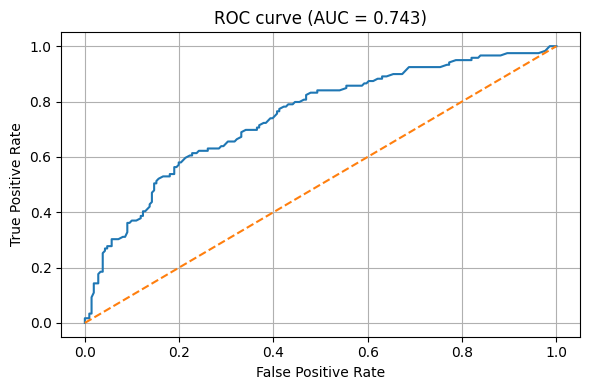

In [ ]:
# Train RandomForest, evaluate, save pipeline & params, plot ROC
# Paste into Google Colab or run locally (install scikit-learn, joblib, matplotlib if needed)

import os, json
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score, classification_report,
    precision_recall_fscore_support, roc_curve, auc as auc_fn
)
import matplotlib.pyplot as plt
import joblib

# ---- Config ----
DATAFILE = 'cipn_generated_more_realistic.csv'   # change if needed
FEATURES = ['vpt','cold_temp','cipn20_sensory','cipn20_motor','cipn20_autonomic']
TARGET = 'label'
TEST_SIZE = 0.15
RANDOM_STATE = 42
OUT_PIPE = 'cipn_rf_pipeline.joblib'
OUT_JSON = 'cipn_rf_params.json'
# ----------------

# Check file
if not os.path.exists(DATAFILE):
    raise FileNotFoundError(f"{DATAFILE} not found. Upload or place the file in working directory.")

# Load data
df = pd.read_csv(DATAFILE)
print("Loaded:", DATAFILE, "rows:", len(df))
print("Label distribution:\n", df[TARGET].value_counts())

# Prepare X, y
X = df[FEATURES].copy()
y = df[TARGET].astype(int).values

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Scale (RF doesn't strictly need it, but helpful for export consistency)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Train RandomForest
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_s, y_train)

# Predict & evaluate
y_prob = rf.predict_proba(X_test_s)[:,1]
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
prec, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary', zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("\n=== RandomForest evaluation ===")
print(f"Train samples: {len(X_train)}   Test samples: {len(X_test)}")
print("Overall label counts:", dict(pd.Series(y).value_counts()))
print(f"Accuracy: {acc:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Precision: {prec:.4f}   Recall (Sensitivity): {recall:.4f}   F1: {f1:.4f}")
print("Confusion matrix (tn, fp, fn, tp):", cm.ravel().tolist())
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

# Save pipeline (imputer + scaler + rf)
pipeline = Pipeline([('imp', imputer), ('sc', scaler), ('rf', rf)])
joblib.dump(pipeline, OUT_PIPE)
print("\nSaved pipeline to:", OUT_PIPE)

# Save preprocessing params for quick on-device/other use
params = {
    'features': FEATURES,
    'imputer_median': dict(zip(FEATURES, imputer.statistics_.tolist())),
    'scaler_mean': dict(zip(FEATURES, scaler.mean_.tolist())),
    'scaler_scale': dict(zip(FEATURES, scaler.scale_.tolist())),
    'model': 'random_forest',
    'n_estimators': rf.n_estimators,
    'random_state': rf.random_state
}
with open(OUT_JSON, 'w') as f:
    json.dump(params, f, indent=2)
print("Saved params to:", OUT_JSON)

# Plot ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc_fn(fpr, tpr)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC curve (AUC = {roc_auc:.3f})')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Cell 1: install required packages (run once)
!pip install -q scikit-learn joblib fastapi uvicorn[standard] pyngrok nest_asyncio requests


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.8/510.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.2/452.2 kB 20.8 MB/s eta 0:00:00


In [ ]:
# Corrected Colab cell: train 2-layer MLP and convert directly from Keras model to TFLite
# (avoids tf.saved_model.save which caused the TypeError in this runtime)

import os, json, sys, subprocess, shutil
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# install TF only if missing
def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade"] + pkgs)

try:
    import tensorflow as tf
except Exception:
    print("Installing tensorflow...")
    pip_install(["tensorflow"])
    import tensorflow as tf

from tensorflow import keras
print("TensorFlow version:", tf.__version__)

# CONFIG
DATAFILE = "cipn_generated_more_realistic.csv"
FEATURES = ['vpt','cold_temp','cipn20_sensory','cipn20_motor','cipn20_autonomic']
TARGET = 'label'
RANDOM_STATE = 42
TEST_SIZE = 0.15

TFLITE_FLOAT = "model.tflite"
TFLITE_QUANT = "model_quant.tflite"
MODEL_HEADER = "model.h"
KERAS_MODEL_FILE = "model.keras"   # fallback if we want a Keras file

# 1) load dataset
if not os.path.exists(DATAFILE):
    raise FileNotFoundError(f"{DATAFILE} not found in Colab workspace. Upload it first.")
df = pd.read_csv(DATAFILE)
if TARGET not in df.columns:
    raise ValueError(f"Target '{TARGET}' not in dataset.")
print("Loaded rows:", len(df))
print("Label counts:\n", df[TARGET].value_counts())

X = df[FEATURES].copy()
y = df[TARGET].astype(int).values

# 2) impute + scale
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X)
scaler = StandardScaler().fit(X_imp)
X_scaled = scaler.transform(X_imp)

# 3) split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
print("Train/test shapes:", X_train.shape, X_test.shape)

# 4) build tiny 2-layer model (1 hidden Dense(16) + output)
def make_small_model(input_dim):
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=(input_dim,)),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

model = make_small_model(X_train.shape[1])
model.summary()

# 5) fit
history = model.fit(X_train, y_train, validation_split=0.12, epochs=30, batch_size=32, verbose=1)

# 6) evaluate
loss, auc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nKeras test AUC = {auc:.4f}")

# 7) Convert to float TFLite directly from Keras model
try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    with open(TFLITE_FLOAT, 'wb') as f:
        f.write(tflite_model)
    print("Saved float TFLite:", TFLITE_FLOAT, "size:", os.path.getsize(TFLITE_FLOAT))
except Exception as e:
    print("Float TFLite conversion failed:", e)
    raise

# 8) Try INT8 quantization (post-training) using representative dataset
def representative_data_gen():
    for i in range(min(200, X_train.shape[0])):
        sample = X_train[i].astype(np.float32).reshape(1, -1)
        yield [sample]

quant_ok = False
try:
    converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
    converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_q.representative_dataset = representative_data_gen
    converter_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter_q.inference_input_type = tf.int8
    converter_q.inference_output_type = tf.int8
    tflite_quant = converter_q.convert()
    with open(TFLITE_QUANT, 'wb') as f:
        f.write(tflite_quant)
    print("Saved quantized TFLite:", TFLITE_QUANT, "size:", os.path.getsize(TFLITE_QUANT))
    quant_ok = True
except Exception as e:
    print("Quantization failed (falling back to float). Error:", e)
    quant_ok = False

chosen = TFLITE_QUANT if quant_ok and os.path.exists(TFLITE_QUANT) and os.path.getsize(TFLITE_QUANT) < os.path.getsize(TFLITE_FLOAT) else TFLITE_FLOAT
print("Chosen model for header export:", chosen)

# 9) Export C header (xxd if available; fallback to Python writer)
def write_header(binfile, headerfile):
    try:
        ret = os.system(f"xxd -i {binfile} > {headerfile}")
        if ret == 0 and os.path.exists(headerfile):
            return headerfile
        else:
            raise RuntimeError("xxd not available or failed")
    except Exception:
        data = open(binfile, "rb").read()
        arr_name = os.path.splitext(os.path.basename(binfile))[0].replace('.', '_')
        with open(headerfile, "w") as f:
            f.write(f"unsigned char {arr_name}[] = {{\n")
            for i, b in enumerate(data):
                f.write(str(b))
                if i != len(data)-1:
                    f.write(",")
                if (i+1) % 16 == 0:
                    f.write("\n")
            f.write("\n};\n")
            f.write(f"unsigned int {arr_name}_len = {len(data)};\n")
        return headerfile

hdr = write_header(chosen, MODEL_HEADER)
print("Wrote model header:", hdr)

# 10) save preproc params
params = {
    'features': FEATURES,
    'imputer_median': dict(zip(FEATURES, imp.statistics_.tolist())),
    'scaler_mean': dict(zip(FEATURES, scaler.mean_.tolist())),
    'scaler_scale': dict(zip(FEATURES, scaler.scale_.tolist()))
}
with open("preproc_params.json", "w") as f:
    json.dump(params, f, indent=2)
print("Saved preproc_params.json")

# 11) parity check on a few rows
print("\nParity check (first 8 test rows):")
interpreter = tf.lite.Interpreter(model_path=chosen)
interpreter.allocate_tensors()
input_det = interpreter.get_input_details()[0]
output_det = interpreter.get_output_details()[0]

rows = X_test[:8].astype(np.float32)
tflite_probs = []
for r in rows:
    inp = r.reshape(1, -1).astype(np.float32)
    if input_det['dtype'] == np.int8:
        scale, zp = input_det['quantization']
        q = (inp / scale + zp).astype(np.int8)
        interpreter.set_tensor(input_det['index'], q)
    else:
        interpreter.set_tensor(input_det['index'], inp)
    interpreter.invoke()
    out = interpreter.get_tensor(output_det['index'])
    if output_det['dtype'] == np.int8:
        scale_o, zp_o = output_det['quantization']
        out = (out.astype(np.float32) - zp_o) * scale_o
    tflite_probs.append(float(out.flatten()[0]))

keras_probs = model.predict(rows).flatten().tolist()
print("Keras probs:", np.round(keras_probs,4))
print("TFLite probs:", np.round(tflite_probs,4))

print("\nDone. Artifacts:", [p for p in os.listdir(".") if p.startswith(("model","preproc","model.h"))])


TensorFlow version: 2.19.0
Loaded rows: 2200
Label counts:
 label
0    1405
1     795
Name: count, dtype: int64
Train/test shapes: (1870, 5) (330, 5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - auc: 0.6432 - loss: 0.6481 - val_auc: 0.6851 - val_loss: 0.6149
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - auc: 0.7251 - loss: 0.5958 - val_auc: 0.7137 - val_loss: 0.5864
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.7654 - loss: 0.5606 - val_auc: 0.7207 - val_loss: 0.5737
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - auc: 0.7543 - loss: 0.5589 - val_auc: 0.7267 - val_loss: 0.5671
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.7636 - loss: 0.5539 - val_auc: 0.7300 - val_loss: 0.5647
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.7784 - loss: 0.5321 - val_auc: 0.7315 - val_loss: 0.5641
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7828 - loss: 0.5216 - val_auc: 0.7324 - val_loss: 0.5633
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7829 - loss: 0.5302 - val_auc: 0.7333 - val_loss: 0.5630
Epoch 9/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7759 - lo

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saved quantized TFLite: model_quant.tflite size: 2544
Chosen model for header export: model.tflite
Wrote model header: model.h
Saved preproc_params.json

Parity check (first 8 test rows):
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Keras probs: [0.1207 0.5767 0.7688 0.3885 0.2571 0.4138 0.152  0.6514]
TFLite probs: [0.1207 0.5767 0.7688 0.3885 0.2571 0.4138 0.152  0.6514]

Done. Artifacts: ['model.h', 'preproc_params.json', 'model.tflite', 'model_quant.tflite']


In [ ]:
#@title 🔄 Upload TFLite file → Generate C header for Arduino / ESP32
from google.colab import files
import os

print("📤 Please upload your .tflite file")
uploaded = files.upload()

# get uploaded filename
tflite_filename = list(uploaded.keys())[0]
basename = os.path.splitext(os.path.basename(tflite_filename))[0]
header_filename = basename + ".h"

# read file bytes
with open(tflite_filename, "rb") as f:
    model_bytes = f.read()

model_size = len(model_bytes)
print(f"\n✅ Model loaded: {tflite_filename}")
print(f"📏 Model size: {model_size} bytes ({model_size/1024:.2f} KB)")

# generate header string
header_lines = []
header_lines.append(f"// Automatically generated from {tflite_filename}")
header_lines.append(f"// Model size: {model_size} bytes ({model_size/1024:.2f} KB)\n")
header_lines.append(f"const unsigned char {basename}[] = {{")

# write bytes as hex
for i, b in enumerate(model_bytes):
    if i % 12 == 0:
        header_lines.append("\n ")
    header_lines.append(f"0x{b:02x}, ")
header_lines.append("\n};")
header_lines.append(f"\nconst unsigned int {basename}_len = {model_size};\n")

# save header
with open(header_filename, "w") as f:
    f.write("\n".join(header_lines))

print(f"\n💾 Header file created: {header_filename}")

# offer download link
files.download(header_filename)


📤 Please upload your .tflite file


Saving student_distilled_int8.tflite to student_distilled_int8 (1).tflite

✅ Model loaded: student_distilled_int8 (1).tflite
📏 Model size: 315568 bytes (308.17 KB)

💾 Header file created: student_distilled_int8 (1).h


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json

# upload your label_map.json first (in Colab or local script)
with open("label_map.json", "r") as f:
    labels = json.load(f)

# Sort by key to keep the same order as training
labels_sorted = [labels[str(i)] for i in sorted(map(int, labels.keys()))]

# Write label_map.h
with open("label_map.h", "w") as f:
    f.write("// Auto-generated label map from label_map.json\n")
    f.write("const char* label_map[%d] = {\n" % len(labels_sorted))
    for lbl in labels_sorted:
        f.write(f'  "{lbl}",\n')
    f.write("};\n")

print("✅ Generated label_map.h")


✅ Generated label_map.h


TensorFlow version: 2.19.0
Loaded rows: 2200
Label counts:
 label
0    1405
1     795
Name: count, dtype: int64
Train/test shapes: (1870, 5) (330, 5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - auc: 0.5390 - loss: 0.7277 - val_auc: 0.6737 - val_loss: 0.6576
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.6729 - loss: 0.6507 - val_auc: 0.7286 - val_loss: 0.6042
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7474 - loss: 0.5975 - val_auc: 0.7485 - val_loss: 0.5744
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7662 - loss: 0.5697 - val_auc: 0.7547 - val_loss: 0.5582
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7844 - loss: 0.5457 - val_auc: 0.7549 - val_loss: 0.5501
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7810 - loss: 0.5443 - val_auc: 0.7534 - val_loss: 0.5466
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7887 - loss: 0.5304 - val_auc: 0.7549 - val_loss: 0.5449
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7962 - loss: 0.5176 - val_auc: 0.7544 - val_loss: 0.5446
Epoch 9/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7788 - loss: 

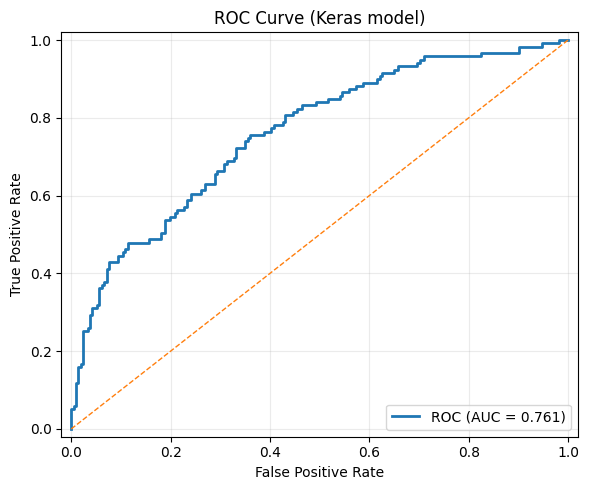

Saved artifact at '/tmp/tmpkf4tbn9j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132714102628304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132714102630608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132714102629264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132714102626384: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved float TFLite: model.tflite size (bytes): 2140 (2.1 KB)
Saved artifact at '/tmp/tmpast1zay3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132714102628304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132714102630608: TensorSpec(shape=(), d

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Keras probs (sample): [0.1044 0.5583 0.8537 0.3868 0.211  0.3324 0.159  0.6705]
TFLite probs (sample): [0.1044 0.5583 0.8537 0.3868 0.211  0.3324 0.159  0.6705]

=== Final summary ===
Keras test AUC         : 0.7613
Keras test accuracy    : 0.7000
Keras precision/recall/f1 : 0.6042/0.4874/0.5395
Float TFLite file      : model.tflite  size=2140 bytes (2.1 KB)
Quant TFLite file      : model_quant.tflite  size=2512 bytes (2.5 KB)
Chosen model (for deployment/header) : model.tflite
Artifacts in workspace: ['roc_curve.png', 'model_quant.tflite', 'preproc_params.json', 'model.h', 'model.tflite']


In [ ]:
# Full Colab cell: train 2-layer MLP, convert to TFLite, produce ROC plot & metrics
# Requirements: cipn_generated_more_realistic.csv uploaded to Colab workspace

import os, json, sys, subprocess, shutil
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_curve, auc, accuracy_score,
                             precision_recall_fscore_support, confusion_matrix)
import matplotlib.pyplot as plt

# install TF if missing (Colab typically has it)
def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade"] + pkgs)

try:
    import tensorflow as tf
except Exception:
    print("Installing tensorflow...")
    pip_install(["tensorflow"])
    import tensorflow as tf

from tensorflow import keras
print("TensorFlow version:", tf.__version__)

# -------- CONFIG ----------
DATAFILE = "cipn_generated_more_realistic.csv"
FEATURES = ['vpt','cold_temp','cipn20_sensory','cipn20_motor','cipn20_autonomic']
TARGET = 'label'
RANDOM_STATE = 42
TEST_SIZE = 0.15

TFLITE_FLOAT = "model.tflite"
TFLITE_QUANT = "model_quant.tflite"
MODEL_HEADER = "model.h"
ROC_PNG = "roc_curve.png"

# -------- load dataset ----------
if not os.path.exists(DATAFILE):
    raise FileNotFoundError(f"{DATAFILE} not found in Colab workspace. Upload it first.")
df = pd.read_csv(DATAFILE)
if TARGET not in df.columns:
    raise ValueError(f"Target '{TARGET}' not in dataset.")
print("Loaded rows:", len(df))
print("Label counts:\n", df[TARGET].value_counts())

X = df[FEATURES].copy()
y = df[TARGET].astype(int).values

# -------- impute + scale ----------
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X)
scaler = StandardScaler().fit(X_imp)
X_scaled = scaler.transform(X_imp)

# -------- split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
print("Train/test shapes:", X_train.shape, X_test.shape)

# -------- build tiny model ----------
def make_small_model(input_dim):
    model = keras.Sequential([
        keras.layers.InputLayer(input_shape=(input_dim,)),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

model = make_small_model(X_train.shape[1])
model.summary()

# -------- fit ----------
history = model.fit(X_train, y_train, validation_split=0.12, epochs=30, batch_size=32, verbose=1)

# -------- evaluate Keras on test ----------
loss, auc_keras = model.evaluate(X_test, y_test, verbose=0)
print(f"\nKeras test AUC = {auc_keras:.4f}")

# additional metrics using Keras probabilities
keras_probs = model.predict(X_test).flatten()
keras_preds = (keras_probs >= 0.5).astype(int)

acc = accuracy_score(y_test, keras_preds)
prec, recall, f1, _ = precision_recall_fscore_support(y_test, keras_preds, average='binary', zero_division=0)
cm = confusion_matrix(y_test, keras_preds)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion matrix:\n", cm)

# -------- ROC curve (Keras) ----------
fpr, tpr, thresholds = roc_curve(y_test, keras_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', linewidth=1)
plt.xlim([-0.02,1.02]); plt.ylim([-0.02,1.02])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve (Keras model)')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(ROC_PNG, dpi=150)
print(f"Saved ROC plot to {ROC_PNG}")
plt.show()

# -------- Convert to float TFLite directly from Keras model ----------
try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    with open(TFLITE_FLOAT, 'wb') as f:
        f.write(tflite_model)
    size_float = os.path.getsize(TFLITE_FLOAT)
    print("Saved float TFLite:", TFLITE_FLOAT, "size (bytes):", size_float, f"({size_float/1024:.1f} KB)")
except Exception as e:
    print("Float TFLite conversion failed:", e)
    raise

# -------- Try INT8 quantization (post-training) using representative dataset ----------
def representative_data_gen():
    # representative dataset expects raw input ranges - we use X_train (already scaled) cast to float32
    for i in range(min(200, X_train.shape[0])):
        sample = X_train[i].astype(np.float32).reshape(1, -1)
        yield [sample]

quant_ok = False
try:
    converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
    converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
    converter_q.representative_dataset = representative_data_gen
    # allow both float and int8 ops; we'll request full-int8 for inference
    converter_q.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter_q.inference_input_type = tf.int8
    converter_q.inference_output_type = tf.int8
    tflite_quant = converter_q.convert()
    with open(TFLITE_QUANT, 'wb') as f:
        f.write(tflite_quant)
    size_quant = os.path.getsize(TFLITE_QUANT)
    print("Saved quantized TFLite:", TFLITE_QUANT, "size (bytes):", size_quant, f"({size_quant/1024:.1f} KB)")
    quant_ok = True
except Exception as e:
    print("Quantization failed (falling back to float). Error:", e)
    quant_ok = False

chosen = TFLITE_QUANT if quant_ok and os.path.exists(TFLITE_QUANT) and os.path.getsize(TFLITE_QUANT) < os.path.getsize(TFLITE_FLOAT) else TFLITE_FLOAT
print("Chosen model for header export:", chosen)

# -------- Export C header (xxd if available; fallback writer) ----------
def write_header(binfile, headerfile):
    try:
        ret = os.system(f"xxd -i {binfile} > {headerfile}")
        if ret == 0 and os.path.exists(headerfile):
            return headerfile
        else:
            raise RuntimeError("xxd not available or failed")
    except Exception:
        data = open(binfile, "rb").read()
        arr_name = os.path.splitext(os.path.basename(binfile))[0].replace('.', '_')
        with open(headerfile, "w") as f:
            f.write(f"unsigned char {arr_name}[] = {{\n")
            for i, b in enumerate(data):
                f.write(str(b))
                if i != len(data)-1:
                    f.write(",")
                if (i+1) % 16 == 0:
                    f.write("\n")
            f.write("\n};\n")
            f.write(f"unsigned int {arr_name}_len = {len(data)};\n")
        return headerfile

hdr = write_header(chosen, MODEL_HEADER)
print("Wrote model header:", hdr)

# -------- Save preproc params ----------
params = {
    'features': FEATURES,
    'imputer_median': dict(zip(FEATURES, imp.statistics_.tolist())),
    'scaler_mean': dict(zip(FEATURES, scaler.mean_.tolist())),
    'scaler_scale': dict(zip(FEATURES, scaler.scale_.tolist()))
}
with open("preproc_params.json", "w") as f:
    json.dump(params, f, indent=2)
print("Saved preproc_params.json")

# -------- Parity check: run TFLite interpreter on a few test rows and compare ----------
print("\nParity check (first 8 test rows):")
interpreter = tf.lite.Interpreter(model_path=chosen)
interpreter.allocate_tensors()
input_det = interpreter.get_input_details()[0]
output_det = interpreter.get_output_details()[0]

rows = X_test[:8].astype(np.float32)
tflite_probs = []
for r in rows:
    inp = r.reshape(1, -1).astype(np.float32)
    # handle quantized input
    if input_det['dtype'] == np.int8:
        scale, zp = input_det['quantization']
        if scale == 0:
            # avoid division by zero
            q = (inp + zp).astype(np.int8)
        else:
            q = (inp / scale + zp).astype(np.int8)
        interpreter.set_tensor(input_det['index'], q)
    else:
        interpreter.set_tensor(input_det['index'], inp)
    interpreter.invoke()
    out = interpreter.get_tensor(output_det['index'])
    if output_det['dtype'] == np.int8:
        scale_o, zp_o = output_det['quantization']
        if scale_o == 0:
            out_f = out.astype(np.float32)
        else:
            out_f = (out.astype(np.float32) - zp_o) * scale_o
        tflite_probs.append(float(out_f.flatten()[0]))
    else:
        tflite_probs.append(float(out.flatten()[0]))

keras_probs_sample = model.predict(rows).flatten().tolist()
print("Keras probs (sample):", np.round(keras_probs_sample,4))
print("TFLite probs (sample):", np.round(tflite_probs,4))

# -------- Print final summary ----------
print("\n=== Final summary ===")
print(f"Keras test AUC         : {roc_auc:.4f}")
print(f"Keras test accuracy    : {acc:.4f}")
print(f"Keras precision/recall/f1 : {prec:.4f}/{recall:.4f}/{f1:.4f}")
if os.path.exists(TFLITE_FLOAT):
    print(f"Float TFLite file      : {TFLITE_FLOAT}  size={os.path.getsize(TFLITE_FLOAT)} bytes ({os.path.getsize(TFLITE_FLOAT)/1024:.1f} KB)")
if os.path.exists(TFLITE_QUANT):
    print(f"Quant TFLite file      : {TFLITE_QUANT}  size={os.path.getsize(TFLITE_QUANT)} bytes ({os.path.getsize(TFLITE_QUANT)/1024:.1f} KB)")
print(f"Chosen model (for deployment/header) : {chosen}")
print("Artifacts in workspace:", [p for p in os.listdir(".") if p.startswith(("model","preproc","model.h", ROC_PNG))])
